In [1]:
geo_path = '/eos/user/j/jrimmer/Geometry'
import sys
sys.path.insert(0, geo_path)
sys.path.insert(0, "../")
sys.path.insert(0, "../scripts")
sys.path.insert(0, "../LicketyFit")
from Geometry.Device import Device

from LicketyFit.Event import *
from LicketyFit.PMT import *

from LicketyFit.Emitter import *

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import uproot, json, awkward as ak
from read_sim_data import *
from plot_event import *

with open('/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/tables/other_mpmt_info_v2.dict', 'rb') as f:
    mpmt_info = pickle.load(f)
    
from particle_range_lookup import *

In [2]:
folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/1kp+_1000MeV_x0y0zn1350.npz"
#folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/mu-/1kmu-_300MeV_x0y0zn1330.npz"
# Get the mapping between wcsim and wcte PMT positions
wcte_mapping = np.loadtxt('../tables/wcsim_wcte_mapping.txt')

# wcsim uses positions 1-19, so have to subtract 1 in the mapping...
sim_wcte_mapping = {}
for i in range(len(wcte_mapping)):
    sim_wcte_mapping[int(wcte_mapping[i][0])] = int(wcte_mapping[i][1]*100 + wcte_mapping[i][2] - 1)
    
    
data_raw = read_sim_data(folder)

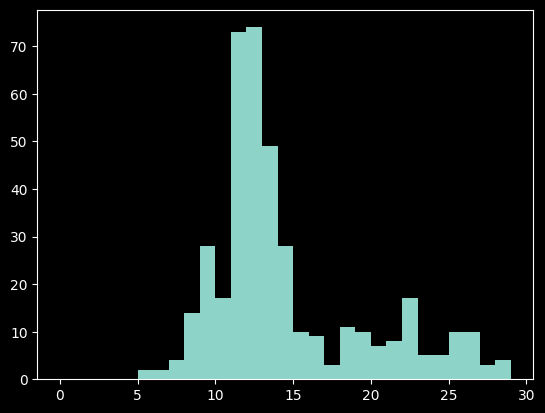

In [52]:
evt_num = 4
plt.hist(data_raw['digi_hit_time'][evt_num],bins = np.arange(0,30));

In [53]:
cut_time = 17

data = {'digi_hit_pmt':[],'digi_hit_time':[],'digi_hit_charge':[]}

for i in range(len(data_raw['digi_hit_time'][evt_num])):
    if 0<data_raw['digi_hit_time'][evt_num][i]<cut_time:
        wcte_pmt = sim_wcte_mapping[data_raw['digi_hit_pmt'][evt_num][i]+1]
        
        data['digi_hit_time'].append(data_raw['digi_hit_time'][evt_num][i])
        data['digi_hit_pmt'].append(wcte_pmt)
        data['digi_hit_charge'].append(data_raw['digi_hit_charge'][evt_num][i])
        
        


In [54]:
particle = ParticleRangeLookup()
particle.particle = 'proton'
particle.energy_to_range_mm(1000)

4428.923054711333

In [55]:
lf_data = np.array([data['digi_hit_pmt'],data['digi_hit_charge'],data['digi_hit_time']]).T

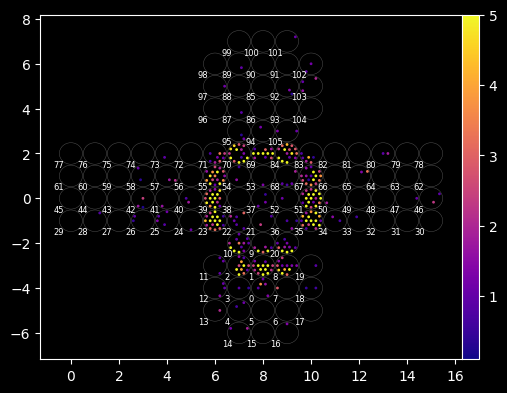

In [56]:
plot_event(lf_data,0)

In [58]:

#   FIT_MODE = "full_length"
#       7-parameter fit:
#           x0, y0, z0, cx, cy, length, t0
#
#       length = full visible track length / dE/dx range-to-threshold
#       ke0    = inferred from length using the particle range table
#
#   FIT_MODE = "absorption"
#       8-parameter fit:
#           x0, y0, z0, cx, cy, visible_length, full_range, t0
#
#       visible_length = visible primary-Cherenkov length before abrupt cutoff
#       full_range     = dE/dx-only range-to-threshold without absorption
#       ke0            = inferred from full_range using the particle range table
#
# Expected input:
#   event_array[:, 0] = PMT ID
#   event_array[:, 1] = charge
#   event_array[:, 2] = time
# =============================================================================

import os
import sys
from pathlib import Path

import numpy as np
from iminuit import Minuit


# =============================================================================
# 1. Path setup
# =============================================================================
WORK_DIR = Path.cwd()
PROJECT_ROOT = WORK_DIR.parent

LICKETYFIT_DIR = PROJECT_ROOT / "LicketyFit"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
TABLES_DIR = PROJECT_ROOT / "tables"

GEOMETRY_PATH = Path("/eos/user/j/jrimmer/Geometry")
GEOMETRY_FILE = GEOMETRY_PATH / "examples/wcte_bldg157.geo"

for p in [PROJECT_ROOT, LICKETYFIT_DIR, SCRIPTS_DIR, TABLES_DIR, GEOMETRY_PATH]:
    p = str(p)
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ["LF_TABLE_DIR"] = str(TABLES_DIR)
os.environ["LF_MULTIPARTICLES_TABLE_DIR"] = str(TABLES_DIR)

# Clear stale notebook imports after changing files on disk.
for mod in list(sys.modules):
    if (
        mod == "particle_cherenkov_model"
        or mod == "LicketyFit.particle_cherenkov_model"
        or mod == "particle_range_lookup"
        or mod == "n_model_wrapper"
        or mod == "LicketyFit.Emitter"
    ):
        del sys.modules[mod]


# =============================================================================
# 2. Imports from cleaned LF_multiParticles
# =============================================================================
from Geometry.Device import Device
from LicketyFit.Event import Event
from LicketyFit.PMT import PMT
from LicketyFit.Emitter import Emitter

from LicketyFit.particle_cherenkov_model import (
    canonical_particle_name,
    set_active_particle,
    cherenkov_threshold_kinetic_mev,
)

from particle_range_lookup import ParticleRangeLookup


# =============================================================================
# 3. User settings
# =============================================================================

FIT_PARTICLE = "proton"       # "muon", "pion", "kaon", "proton"
FIT_MODE = "absorption"       # "full_length" or "absorption"

# Fixed fit parameters:
#   Put a number for any parameter you want Minuit to hold fixed.
#   Leave the value as None to let that parameter float normally.
#
# full_length mode parameters:
#   x0, y0, z0, cx, cy, length, t0
#
# absorption mode parameters:
#   x0, y0, z0, cx, cy, visible_length, full_range, t0
#
# absorption mode also supports this derived fixed parameter:
#   ke0_mev
#
# Important:
#   In absorption mode, "full_range" is the dE/dx range-to-threshold.
#   The initial kinetic energy ke0 is inferred from full_range.
#   Therefore, if you want to fix the full unabsorbed track / initial KE and
#   fit only the pre-absorption visible length, set "ke0_mev" and leave
#   "visible_length" as None.
#
# Examples:
#   Fix geometry and direction, but fit the lengths:
#       FIXED_FIT_PARAMS = {"x0": 0.0, "y0": 0.0, "cx": 0.0, "cy": 0.0}
#
#   full_length mode: fix the full visible range directly:
#       FIXED_FIT_PARAMS = {"length": 1200.0}
#
#   absorption mode: fix the initial kinetic energy, fit visible_length:
#       FIXED_FIT_PARAMS = {"ke0_mev": 1000.0}
#
#   absorption mode: fix the equivalent full unabsorbed range directly:
#       FIXED_FIT_PARAMS = {"full_range": 2500.0}
#
# Do not set both "ke0_mev" and "full_range" at the same time.
FIXED_FIT_PARAMS = {
    "x0": None,
    "y0": None,
    "z0": -1350.0,
    "cx": None,
    "cy": None,

    # full_length mode only.
    "length": None,

    # absorption mode only.
    # Set ke0_mev to fix the unabsorbed full range through the particle range table.
    # With ke0_mev fixed and visible_length=None, Minuit fits only the length
    # before absorption while holding the initial kinetic energy fixed.
    "visible_length": None,
    "full_range": None,
    "ke0_mev": 1000.0,

    "t0": None,
}

# PMT ID mode:
#   "wcte"  -> PMT ID is already slot*100 + pmt_position
#   "wcsim" -> PMT ID is raw WCSim tube ID and tables/wcsim_wcte_mapping.txt exists
PMT_ID_MODE = "wcte"
WCSIM_MAPPING_ADD_ONE = True

# For WCSim-style predictions, usually use design geometry.
# For real-data geometry/calibration comparisons, you may want "est".
PMT_PLACEMENT = "design"      # "design" or "est"

PE_SCALE = 1.0

USE_CHARGE_LIKELIHOOD = True
USE_TIMING_LIKELIHOOD = True
USE_T0_PRIOR = False

M_STRAT = 1
NCALL_SIMPLEX = 30000
NCALL_MIGRAD = 70000
T0_LIMITS = (-2.0, 2.0)

INACTIVE_SLOTS = [27, 32, 45, 74, 77, 79, 85, 91, 99]

OUTER_RING = np.array([0, 7, 19, 34, 50, 66, 82, 83, 105, 94, 95, 71, 72, 56, 40, 24, 11, 3, 18])
INNER_RING = np.array([1, 8, 35, 51, 67, 84, 69, 70, 55, 39, 23, 10, 2, 20, 36, 52, 68, 53, 54, 38, 22, 21, 37, 9])
ALL_RING = np.arange(0, 106)

RING_MASK_MODE = "both"       # "none", "pes", "ts", "both"


# -----------------------------------------------------------------------------
# Seed grids
# -----------------------------------------------------------------------------
FAST_SEED_X0 = [-150.0, 0.0, 150.0]
FAST_SEED_Y0 = [-150.0, 0.0, 150.0]
FAST_SEED_Z0 = [-1500.0, -1400.0, -1300.0, -1200.0, -1100.0, -1000.0]

# Used in full_length mode.
FAST_SEED_LENGTHS = [
    100.0, 150.0, 200.0, 250.0, 300.0, 350.0, 400.0, 450.0, 500.0,
    550.0, 600.0, 700.0, 900.0, 1100.0, 1300.0, 1500.0, 1700.0, 1900.0
]

# Used in absorption mode.
FAST_SEED_VISIBLE_LENGTHS = [
    100.0, 150.0, 200.0, 250.0, 300.0, 350.0, 400.0, 450.0, 500.0,
    550.0, 600.0, 700.0, 900.0, 1100.0, 1300.0, 1500.0, 1700.0, 1900.0
]

# Converted into full_range seeds through the range table.
FAST_SEED_KE0_MEV = [600.0, 800.0, 1000.0, 1200.0, 1500.0, 2000.0]

# Extra direct full_range seeds in mm.
FAST_SEED_FULL_RANGES_MM = [300.0, 600.0, 1000.0, 1500.0, 2200.0, 3000.0]

FAST_SEED_DIRECTIONS = [
    (0.0, 0.0),
    (0.04, 0.0),
    (-0.04, 0.0),
    (0.0, 0.04),
    (0.0, -0.04),
]


# =============================================================================
# 4. Mode helpers
# =============================================================================
def canonical_fit_mode(mode):
    key = str(mode).strip().lower()

    if key in {"full_length", "full", "threshold", "range", "7", "7param", "7_param"}:
        return "full_length"

    if key in {"absorption", "absorbed", "abrupt", "abrupt_8param", "8", "8param", "8_param"}:
        return "absorption"

    raise ValueError("FIT_MODE must be 'full_length' or 'absorption'")


FIT_MODE = canonical_fit_mode(FIT_MODE)


FULL_LENGTH_PARAM_NAMES = ("x0", "y0", "z0", "cx", "cy", "length", "t0")
ABSORPTION_PARAM_NAMES = ("x0", "y0", "z0", "cx", "cy", "visible_length", "full_range", "t0")

# "ke0_mev" is not a Minuit parameter. It is a user-facing alias that is
# converted into the Minuit parameter "full_range" after the range table exists.
DERIVED_FIXED_PARAM_NAMES = ("ke0_mev",)

ALL_FIT_PARAM_NAMES = tuple(dict.fromkeys(FULL_LENGTH_PARAM_NAMES + ABSORPTION_PARAM_NAMES))
ALL_FIXED_PARAM_NAMES = tuple(dict.fromkeys(ALL_FIT_PARAM_NAMES + DERIVED_FIXED_PARAM_NAMES))


def parameter_names_for_mode(fit_mode):
    fit_mode = canonical_fit_mode(fit_mode)

    if fit_mode == "full_length":
        return FULL_LENGTH_PARAM_NAMES

    if fit_mode == "absorption":
        return ABSORPTION_PARAM_NAMES

    raise ValueError("fit_mode must be 'full_length' or 'absorption'")


def fixed_parameter_names_for_mode(fit_mode):
    """User-facing names that may appear in FIXED_FIT_PARAMS for this mode."""
    fit_mode = canonical_fit_mode(fit_mode)

    if fit_mode == "full_length":
        return FULL_LENGTH_PARAM_NAMES

    if fit_mode == "absorption":
        return tuple(dict.fromkeys(ABSORPTION_PARAM_NAMES + DERIVED_FIXED_PARAM_NAMES))

    raise ValueError("fit_mode must be 'full_length' or 'absorption'")


def _range_from_fixed_ke0_mev(range_lookup, ke0_mev):
    """Convert fixed initial kinetic energy to full_range using the range table."""
    if range_lookup is None:
        raise ValueError(
            "FIXED_FIT_PARAMS['ke0_mev'] needs the ParticleRangeLookup. "
            "Call normalize_fixed_fit_params(..., range_lookup=range_lookup)."
        )

    ke0_mev = float(ke0_mev)
    if not np.isfinite(ke0_mev) or ke0_mev <= 0.0:
        raise ValueError(f"Fixed ke0_mev must be finite and > 0, got {ke0_mev}")

    min_ke = float(range_lookup.initial_energies_mev[0])
    max_ke = float(range_lookup.initial_energies_mev[-1])
    if ke0_mev < min_ke or ke0_mev > max_ke:
        raise ValueError(
            f"Fixed ke0_mev={ke0_mev} is outside the range table bounds "
            f"[{min_ke}, {max_ke}] MeV."
        )

    full_range = float(range_lookup.energy_to_range_mm(ke0_mev))
    if not np.isfinite(full_range) or full_range <= 0.0:
        raise ValueError(
            f"Could not convert fixed ke0_mev={ke0_mev} into a finite positive full_range."
        )

    return full_range


def normalize_fixed_fit_params(fit_mode, fixed_params=None, range_lookup=None):
    """Return Minuit-level fixed parameters for the chosen fit mode.

    A parameter is fixed by setting FIXED_FIT_PARAMS[name] to a finite number.
    A parameter is floated by leaving FIXED_FIT_PARAMS[name] as None.

    In absorption mode only, FIXED_FIT_PARAMS may include "ke0_mev".
    Because ke0 is not itself a Minuit parameter, "ke0_mev" is converted into
    "full_range" through range_lookup.energy_to_range_mm(ke0_mev). This lets you
    fix the unabsorbed full track / initial KE while still fitting visible_length.
    """
    if fixed_params is None:
        fixed_params = {}

    if not isinstance(fixed_params, dict):
        raise TypeError("fixed_params must be a dictionary mapping parameter names to values or None")

    fit_mode = canonical_fit_mode(fit_mode)
    active = set(fixed_parameter_names_for_mode(fit_mode))
    all_known = set(ALL_FIXED_PARAM_NAMES)

    raw = dict(fixed_params)

    has_fixed_ke0 = raw.get("ke0_mev", None) is not None
    has_fixed_full_range = raw.get("full_range", None) is not None

    if has_fixed_ke0:
        if fit_mode != "absorption":
            raise ValueError("Fixed parameter 'ke0_mev' is only valid in FIT_MODE='absorption'.")

        if has_fixed_full_range:
            raise ValueError(
                "Do not set both FIXED_FIT_PARAMS['ke0_mev'] and "
                "FIXED_FIT_PARAMS['full_range']. Set one or the other."
            )

        raw["full_range"] = _range_from_fixed_ke0_mev(range_lookup, raw["ke0_mev"])

    # From this point onward, "ke0_mev" is only metadata. Minuit fixes full_range.
    raw["ke0_mev"] = None

    cleaned = {}

    for name, value in raw.items():
        if value is None:
            continue

        if name not in all_known:
            raise ValueError(
                f"Unknown fixed parameter {name!r}. Known parameters are: {ALL_FIXED_PARAM_NAMES}"
            )

        if name not in active:
            raise ValueError(
                f"Fixed parameter {name!r} is not valid for FIT_MODE={fit_mode!r}. "
                f"Valid fixed parameters for this mode are: {fixed_parameter_names_for_mode(fit_mode)}"
            )

        value = float(value)
        if not np.isfinite(value):
            raise ValueError(f"Fixed parameter {name!r} must be finite, got {value}")

        if name in {"length", "full_range"} and value <= 0.0:
            raise ValueError(f"Fixed parameter {name!r} must be > 0, got {value}")

        if name == "visible_length" and value < 0.0:
            raise ValueError(f"Fixed parameter 'visible_length' must be >= 0, got {value}")

        # Keep fixed values inside the same limits that are later assigned to Minuit.
        # This avoids Minuit silently moving a fixed starting value onto a boundary.
        hard_limits = {
            "x0": (-2000.0, 2000.0),
            "y0": (-2000.0, 2000.0),
            "z0": (-2000.0, 2000.0),
            "cx": (-0.5, 0.5),
            "cy": (-0.5, 0.5),
            "t0": tuple(float(x) for x in T0_LIMITS),
            "length": (1.0, 6000.0),
            "visible_length": (0.0, 6000.0),
            "full_range": (1.0, 6000.0),
        }

        lo, hi = hard_limits[name]
        if value < lo or value > hi:
            raise ValueError(
                f"Fixed parameter {name!r}={value} is outside its allowed range [{lo}, {hi}]."
            )

        cleaned[name] = value

    if fit_mode == "absorption":
        if {"visible_length", "full_range"}.issubset(cleaned):
            if cleaned["visible_length"] > cleaned["full_range"]:
                raise ValueError(
                    "In absorption mode, fixed visible_length cannot exceed fixed full_range."
                )

    if "cx" in cleaned and "cy" in cleaned:
        if cleaned["cx"] * cleaned["cx"] + cleaned["cy"] * cleaned["cy"] >= 1.0:
            raise ValueError("Fixed cx and cy imply cx^2 + cy^2 >= 1, so the direction is invalid.")

    return cleaned


def fixed_param_report(fit_mode, fixed_params, range_lookup):
    """Small summary dictionary for printing and result storage."""
    fit_mode = canonical_fit_mode(fit_mode)
    fixed_params = normalize_fixed_fit_params(fit_mode, fixed_params, range_lookup=range_lookup)

    report = dict(fixed_params)

    if fit_mode == "absorption" and "full_range" in fixed_params:
        report["ke0_mev"] = float(range_lookup.range_mm_to_energy(fixed_params["full_range"]))

    if fit_mode == "full_length" and "length" in fixed_params:
        report["ke0_mev"] = float(range_lookup.range_mm_to_energy(fixed_params["length"]))

    return report


def apply_fixed_params_to_seed(seed, fixed_params):
    out = dict(seed)
    for name, value in fixed_params.items():
        if name in out:
            out[name] = float(value)
    return out


def free_parameter_names_for_mode(fit_mode, fixed_params, range_lookup=None):
    fixed = set(normalize_fixed_fit_params(fit_mode, fixed_params, range_lookup=range_lookup))
    return tuple(name for name in parameter_names_for_mode(fit_mode) if name not in fixed)



# =============================================================================
# 5. PMT mapping and event helpers
# =============================================================================
def load_wcsim_to_wcte_mapping(mapping_path=None):
    if mapping_path is None:
        mapping_path = TABLES_DIR / "wcsim_wcte_mapping.txt"

    mapping_path = Path(mapping_path)
    if not mapping_path.exists():
        raise FileNotFoundError(f"Missing WCSim mapping file: {mapping_path}")

    arr = np.loadtxt(mapping_path)

    mapping = {}
    for row in np.atleast_2d(arr):
        wcsim_id = int(row[0])
        slot = int(row[1])
        pmt_pos = int(row[2]) - 1
        mapping[wcsim_id] = slot * 100 + pmt_pos

    return mapping


def convert_input_pmt_id_to_wcte(raw_pmt_id, *, pmt_id_mode="wcte", mapping=None):
    raw_pmt_id = int(raw_pmt_id)

    if pmt_id_mode == "wcte":
        return raw_pmt_id

    if pmt_id_mode == "wcsim":
        if mapping is None:
            raise ValueError("mapping must be provided when pmt_id_mode='wcsim'")

        key = raw_pmt_id + 1 if WCSIM_MAPPING_ADD_ONE else raw_pmt_id
        if key not in mapping:
            raise KeyError(f"WCSim PMT ID {raw_pmt_id} with lookup key {key} not found.")

        return int(mapping[key])

    raise ValueError("PMT_ID_MODE must be 'wcte' or 'wcsim'")


def array_to_event(hit_array, *, pmt_id_mode="wcte", inactive_slots=None):
    hit_array = np.asarray(hit_array)

    if hit_array.ndim != 2 or hit_array.shape[1] < 3:
        raise ValueError("hit_array must have shape (N_hits, 3): [PMT ID, charge, time]")

    inactive_slots = set([] if inactive_slots is None else [int(s) for s in inactive_slots])

    mapping = None
    if pmt_id_mode == "wcsim":
        mapping = load_wcsim_to_wcte_mapping()

    ev = Event(0, 0, 106)
    ev.set_mpmt_status(list(range(106)), True)

    for slot in range(106):
        if slot in inactive_slots:
            ev.set_pmt_status(slot, list(range(ev.npmt_per_mpmt)), False)
        else:
            ev.set_pmt_status(slot, list(range(ev.npmt_per_mpmt)), True)

    skipped = 0

    for raw_pmt_id, charge, time in hit_array[:, :3]:
        try:
            wcte_pmt = convert_input_pmt_id_to_wcte(
                raw_pmt_id,
                pmt_id_mode=pmt_id_mode,
                mapping=mapping,
            )
        except Exception:
            skipped += 1
            continue

        slot = int(wcte_pmt // 100)
        pmt_pos = int(wcte_pmt % 100)

        if slot < 0 or slot >= ev.n_mpmt:
            skipped += 1
            continue

        if pmt_pos < 0 or pmt_pos >= ev.npmt_per_mpmt:
            skipped += 1
            continue

        if not ev.pmt_status[slot][pmt_pos]:
            continue

        ev.hit_charges[slot][pmt_pos].append(float(charge))
        ev.hit_times[slot][pmt_pos].append(float(time))

    if skipped:
        print(f"Skipped {skipped} hits because their PMT IDs were invalid/unmapped.")

    return ev


def build_observables_from_event(ev, WCD, *, pe_scale=1.0):
    obs_pes = []
    obs_ts = []

    for i_mpmt in range(ev.n_mpmt):
        if not ev.mpmt_status[i_mpmt]:
            continue

        mpmt = WCD.mpmts[i_mpmt]
        if mpmt is None:
            continue

        for i_pmt in range(ev.npmt_per_mpmt):
            if not ev.pmt_status[i_mpmt][i_pmt]:
                continue

            if mpmt.pmts[i_pmt] is None:
                continue

            q = np.asarray(ev.hit_charges[i_mpmt][i_pmt], dtype=np.float64)
            t = np.asarray(ev.hit_times[i_mpmt][i_pmt], dtype=np.float64)

            if q.size == 0:
                obs_pes.append(0.0)
                obs_ts.append(np.nan)
            else:
                obs_pes.append(float(np.sum(q)) / pe_scale)
                obs_ts.append(float(np.sum(q * t) / np.sum(q)))

    return np.asarray(obs_pes, dtype=np.float64), np.asarray(obs_ts, dtype=np.float64)


def apply_ring_mask_to_observables(obs_pes, obs_ts, ring_keep_mask, *, mode="both"):
    obs_pes = np.asarray(obs_pes, dtype=np.float64).copy()
    obs_ts = np.asarray(obs_ts, dtype=np.float64).copy()

    if mode not in {"none", "pes", "ts", "both"}:
        raise ValueError("mode must be one of: 'none', 'pes', 'ts', 'both'")

    if mode in {"pes", "both"}:
        obs_pes[~ring_keep_mask] = 0.0

    if mode in {"ts", "both"}:
        obs_ts[~ring_keep_mask] = np.nan

    return obs_pes, obs_ts


def get_pmt_placements_with_ids(event, WCD, place_info):
    p_locations = []
    direction_zs = []
    mpmt_slots = []
    pmt_ids = []

    for i_mpmt in range(event.n_mpmt):
        if not event.mpmt_status[i_mpmt]:
            continue

        mpmt = WCD.mpmts[i_mpmt]
        if mpmt is None:
            continue

        for i_pmt in range(event.npmt_per_mpmt):
            if not event.pmt_status[i_mpmt][i_pmt]:
                continue

            pmt = mpmt.pmts[i_pmt]
            if pmt is None:
                continue

            try:
                placement = pmt.get_placement(place_info, WCD)
            except TypeError:
                placement = pmt.get_placement(place_info)

            p_locations.append(np.asarray(placement["location"], dtype=np.float64))
            direction_zs.append(np.asarray(placement["direction_z"], dtype=np.float64))
            mpmt_slots.append(int(i_mpmt))
            pmt_ids.append(int(i_mpmt * 100 + i_pmt))

    return (
        np.asarray(p_locations, dtype=np.float64),
        np.asarray(direction_zs, dtype=np.float64),
        np.asarray(mpmt_slots, dtype=np.int64),
        np.asarray(pmt_ids, dtype=np.int64),
    )


def unit_direction_from_cxcy(cx, cy):
    cx = float(cx)
    cy = float(cy)

    cz2 = 1.0 - cx * cx - cy * cy
    if cz2 <= 0.0:
        raise ValueError(f"Invalid direction: cx^2 + cy^2 = {cx*cx + cy*cy} >= 1")

    return (cx, cy, float(np.sqrt(cz2)))


# =============================================================================
# 6. Seed grid
# =============================================================================
def build_sparse_geometry_variants():
    variants = []

    for x0 in FAST_SEED_X0:
        variants.append({"x0": float(x0), "y0": 0.0, "cx": 0.0, "cy": 0.0})

    for y0 in FAST_SEED_Y0:
        variants.append({"x0": 0.0, "y0": float(y0), "cx": 0.0, "cy": 0.0})

    for cx, cy in FAST_SEED_DIRECTIONS:
        variants.append({"x0": 0.0, "y0": 0.0, "cx": float(cx), "cy": float(cy)})

    unique = []
    seen = set()

    for v in variants:
        sig = (v["x0"], v["y0"], v["cx"], v["cy"])
        if sig not in seen:
            seen.add(sig)
            unique.append(v)

    return unique


def build_full_range_seed_values(range_lookup):
    values = []

    for ke in FAST_SEED_KE0_MEV:
        try:
            r = range_lookup.energy_to_range_mm(float(ke))
        except Exception:
            continue

        if np.isfinite(r) and r > 0:
            values.append(float(r))

    values.extend(float(r) for r in FAST_SEED_FULL_RANGES_MM)

    max_r = float(range_lookup.overall_distances_mm[-1])
    values = [r for r in values if np.isfinite(r) and 0.0 < r <= max_r]

    unique = []
    seen = set()

    for r in values:
        key = round(float(r), 6)
        if key not in seen:
            seen.add(key)
            unique.append(float(r))

    return unique


def build_fast_seed_grid(range_lookup, fit_mode, fixed_params=None):
    fit_mode = canonical_fit_mode(fit_mode)
    fixed_params = normalize_fixed_fit_params(fit_mode, fixed_params, range_lookup=range_lookup)

    geom_variants = build_sparse_geometry_variants()
    seeds = []

    if fit_mode == "full_length":
        max_r = float(range_lookup.overall_distances_mm[-1])

        z0_values = [fixed_params["z0"]] if "z0" in fixed_params else FAST_SEED_Z0
        length_values = [fixed_params["length"]] if "length" in fixed_params else FAST_SEED_LENGTHS
        length_values = [float(x) for x in length_values if 0.0 < float(x) <= max_r]

        if len(length_values) == 0:
            raise ValueError("No valid length seed values remain after applying fixed parameters.")

        for z0 in z0_values:
            for length in length_values:
                for geom in geom_variants:
                    seed = {
                        "x0": float(geom["x0"]),
                        "y0": float(geom["y0"]),
                        "z0": float(z0),
                        "cx": float(geom["cx"]),
                        "cy": float(geom["cy"]),
                        "length": float(length),
                        "t0": 0.0,
                    }
                    seed = apply_fixed_params_to_seed(seed, fixed_params)
                    seeds.append(seed)

        keys = FULL_LENGTH_PARAM_NAMES

    elif fit_mode == "absorption":
        full_range_values = build_full_range_seed_values(range_lookup)

        z0_values = [fixed_params["z0"]] if "z0" in fixed_params else FAST_SEED_Z0
        visible_length_values = (
            [fixed_params["visible_length"]]
            if "visible_length" in fixed_params
            else FAST_SEED_VISIBLE_LENGTHS
        )
        full_range_values = (
            [fixed_params["full_range"]]
            if "full_range" in fixed_params
            else full_range_values
        )

        max_r = float(range_lookup.overall_distances_mm[-1])
        visible_length_values = [
            float(x) for x in visible_length_values
            if 0.0 <= float(x) <= max_r
        ]
        full_range_values = [
            float(x) for x in full_range_values
            if 0.0 < float(x) <= max_r
        ]

        if len(visible_length_values) == 0:
            raise ValueError("No valid visible_length seed values remain after applying fixed parameters.")
        if len(full_range_values) == 0:
            raise ValueError("No valid full_range seed values remain after applying fixed parameters.")

        for z0 in z0_values:
            for visible_length in visible_length_values:
                for full_range in full_range_values:
                    if visible_length > full_range:
                        continue

                    for geom in geom_variants:
                        seed = {
                            "x0": float(geom["x0"]),
                            "y0": float(geom["y0"]),
                            "z0": float(z0),
                            "cx": float(geom["cx"]),
                            "cy": float(geom["cy"]),
                            "visible_length": float(visible_length),
                            "full_range": float(full_range),
                            "t0": 0.0,
                        }
                        seed = apply_fixed_params_to_seed(seed, fixed_params)

                        # This check is repeated after applying fixed x/y/cx/cy/t0 too, so that
                        # fixed visible_length/full_range choices are respected exactly.
                        if seed["visible_length"] > seed["full_range"]:
                            continue

                        seeds.append(seed)

        keys = ABSORPTION_PARAM_NAMES

    else:
        raise ValueError("fit_mode must be 'full_length' or 'absorption'")

    unique = []
    seen = set()

    for seed in seeds:
        sig = tuple(seed[k] for k in keys)
        if sig not in seen:
            seen.add(sig)
            unique.append(seed)

    if len(unique) == 0:
        raise RuntimeError("No valid seed points remain after applying fixed parameters.")

    return unique

# =============================================================================
# 7. Likelihood helpers
# =============================================================================
def get_timing_only_nll(exp_pes, obs_pes, exp_ts, obs_ts, pmt_model):
    exp_pes = np.asarray(exp_pes, dtype=np.float64)
    obs_pes = np.asarray(obs_pes, dtype=np.float64)
    exp_ts = np.asarray(exp_ts, dtype=np.float64)
    obs_ts = np.asarray(obs_ts, dtype=np.float64)

    mask = (
        (exp_pes > 0.0)
        & (obs_pes > 0.0)
        & np.isfinite(exp_ts)
        & np.isfinite(obs_ts)
    )

    if not np.any(mask):
        return 1e30

    sigma_t = pmt_model.single_pe_time_std / np.sqrt(obs_pes[mask])
    dt = (obs_ts[mask] - exp_ts[mask]) / sigma_t

    return float(0.5 * np.sum(dt * dt))


def evaluate_pmt_nll(exp_pes, obs_pes, exp_ts, obs_ts, pmt_model):
    if USE_CHARGE_LIKELIHOOD and USE_TIMING_LIKELIHOOD:
        return pmt_model.get_neg_log_likelihood_npe_t(
            exp_pes,
            obs_pes,
            exp_ts,
            obs_ts,
        )

    if USE_CHARGE_LIKELIHOOD:
        return pmt_model.get_neg_log_likelihood_npe(exp_pes, obs_pes)

    return get_timing_only_nll(exp_pes, obs_pes, exp_ts, obs_ts, pmt_model)


def evaluate_neg_log_likelihood_full_length(
    obs_pes,
    obs_ts,
    emitter,
    p_locations,
    direction_zs,
    WCD,
    pmt_model,
    range_lookup,
    x0,
    y0,
    z0,
    cx,
    cy,
    length,
    t0,
):
    length = float(length)

    if not np.isfinite(length) or length <= 0.0:
        return 1e30

    if length > float(range_lookup.overall_distances_mm[-1]):
        return 1e30

    cz2 = 1.0 - cx * cx - cy * cy
    if cz2 <= 0.0:
        return 1e30

    emitter.start_coord = (float(x0), float(y0), float(z0))
    emitter.starting_time = float(t0)
    emitter.direction = (float(cx), float(cy), float(np.sqrt(cz2)))

    # full_length mode:
    #   length is the full dE/dx range-to-threshold.
    #   initial KE is inferred from the range table inside the Emitter.
    init_ke = emitter.refresh_kinematics_from_length(length)

    if hasattr(emitter, "visible_length_is_physical"):
        if not emitter.visible_length_is_physical():
            return 1e30
    elif getattr(emitter, "last_visible_length_exceeds_range", False):
        return 1e30

    s = emitter.get_emission_points(p_locations, init_ke)

    exp_pes, exp_ts = emitter.get_expected_pes_ts(
        WCD,
        s,
        p_locations,
        direction_zs,
        None,
        obs_pes,
    )

    nll = evaluate_pmt_nll(exp_pes, obs_pes, exp_ts, obs_ts, pmt_model)

    if not np.isfinite(nll):
        return 1e30

    return float(nll)


def evaluate_neg_log_likelihood_absorption(
    obs_pes,
    obs_ts,
    emitter,
    p_locations,
    direction_zs,
    WCD,
    pmt_model,
    range_lookup,
    x0,
    y0,
    z0,
    cx,
    cy,
    visible_length,
    full_range,
    t0,
):
    visible_length = float(visible_length)
    full_range = float(full_range)

    if not np.isfinite(visible_length) or not np.isfinite(full_range):
        return 1e30

    if visible_length < 0.0 or full_range <= 0.0:
        return 1e30

    if visible_length > full_range:
        return 1e30

    if full_range > float(range_lookup.overall_distances_mm[-1]):
        return 1e30

    cz2 = 1.0 - cx * cx - cy * cy
    if cz2 <= 0.0:
        return 1e30

    ke0 = float(range_lookup.range_mm_to_energy(full_range))

    if not np.isfinite(ke0):
        return 1e30

    threshold = cherenkov_threshold_kinetic_mev(emitter.particle_mass)
    if ke0 <= threshold:
        return 1e30

    emitter.start_coord = (float(x0), float(y0), float(z0))
    emitter.starting_time = float(t0)
    emitter.direction = (float(cx), float(cy), float(np.sqrt(cz2)))

    # absorption mode:
    #   full_range -> ke0 controls K(s), beta(s), theta_c(s)
    #   visible_length controls where primary light is abruptly truncated.
    emitter.fixed_initial_KE = ke0

    init_ke = emitter.refresh_kinematics_from_length(visible_length)

    if hasattr(emitter, "visible_length_is_physical"):
        if not emitter.visible_length_is_physical():
            return 1e30
    elif getattr(emitter, "last_visible_length_exceeds_range", False):
        return 1e30

    s = emitter.get_emission_points(p_locations, init_ke)

    exp_pes, exp_ts = emitter.get_expected_pes_ts(
        WCD,
        s,
        p_locations,
        direction_zs,
        None,
        obs_pes,
    )

    nll = evaluate_pmt_nll(exp_pes, obs_pes, exp_ts, obs_ts, pmt_model)

    if not np.isfinite(nll):
        return 1e30

    return float(nll)


def evaluate_neg_log_likelihood(
    fit_mode,
    obs_pes,
    obs_ts,
    emitter,
    p_locations,
    direction_zs,
    WCD,
    pmt_model,
    range_lookup,
    params,
):
    if fit_mode == "full_length":
        return evaluate_neg_log_likelihood_full_length(
            obs_pes,
            obs_ts,
            emitter,
            p_locations,
            direction_zs,
            WCD,
            pmt_model,
            range_lookup,
            params["x0"],
            params["y0"],
            params["z0"],
            params["cx"],
            params["cy"],
            params["length"],
            params["t0"],
        )

    if fit_mode == "absorption":
        return evaluate_neg_log_likelihood_absorption(
            obs_pes,
            obs_ts,
            emitter,
            p_locations,
            direction_zs,
            WCD,
            pmt_model,
            range_lookup,
            params["x0"],
            params["y0"],
            params["z0"],
            params["cx"],
            params["cy"],
            params["visible_length"],
            params["full_range"],
            params["t0"],
        )

    raise ValueError("fit_mode must be 'full_length' or 'absorption'")


def select_best_initial_seed(
    fit_mode,
    obs_pes,
    obs_ts,
    init_param_sets,
    emitter_template,
    p_locations,
    direction_zs,
    WCD,
    pmt_model,
    range_lookup,
):
    seed_scan = []

    for i, seed in enumerate(init_param_sets):
        emitter = emitter_template.copy()

        fval = evaluate_neg_log_likelihood(
            fit_mode,
            obs_pes,
            obs_ts,
            emitter,
            p_locations,
            direction_zs,
            WCD,
            pmt_model,
            range_lookup,
            seed,
        )

        if not np.isfinite(fval):
            fval = np.inf

        seed_scan.append({
            "seed_index": int(i),
            "fval": float(fval),
            "params": dict(seed),
        })

    seed_scan_sorted = sorted(seed_scan, key=lambda x: x["fval"])

    if len(seed_scan_sorted) == 0 or not np.isfinite(seed_scan_sorted[0]["fval"]):
        raise RuntimeError("All initial seeds gave non-finite FCN values.")

    best = seed_scan_sorted[0]
    return dict(best["params"]), int(best["seed_index"]), float(best["fval"]), seed_scan_sorted


# =============================================================================
# 8. Minuit and prediction helpers
# =============================================================================
def make_minuit_for_single_event(
    fit_mode,
    obs_pes,
    obs_ts,
    start_params,
    emitter_template,
    p_locations,
    direction_zs,
    WCD,
    pmt_model,
    range_lookup,
    fixed_params=None,
):
    fit_mode = canonical_fit_mode(fit_mode)
    fixed_params = normalize_fixed_fit_params(fit_mode, fixed_params, range_lookup=range_lookup)
    start_params = apply_fixed_params_to_seed(start_params, fixed_params)

    emitter = emitter_template.copy()
    max_range = float(range_lookup.overall_distances_mm[-1])

    if fit_mode == "full_length":

        def nll(x0, y0, z0, cx, cy, length, t0):
            params = {
                "x0": x0,
                "y0": y0,
                "z0": z0,
                "cx": cx,
                "cy": cy,
                "length": length,
                "t0": t0,
            }
            return evaluate_neg_log_likelihood(
                fit_mode,
                obs_pes,
                obs_ts,
                emitter,
                p_locations,
                direction_zs,
                WCD,
                pmt_model,
                range_lookup,
                params,
            )

        m = Minuit(nll, **start_params)

        m.limits["length"] = (1.0, 6000)
        m.errors["length"] = 60.0

    elif fit_mode == "absorption":

        def nll(x0, y0, z0, cx, cy, visible_length, full_range, t0):
            params = {
                "x0": x0,
                "y0": y0,
                "z0": z0,
                "cx": cx,
                "cy": cy,
                "visible_length": visible_length,
                "full_range": full_range,
                "t0": t0,
            }
            return evaluate_neg_log_likelihood(
                fit_mode,
                obs_pes,
                obs_ts,
                emitter,
                p_locations,
                direction_zs,
                WCD,
                pmt_model,
                range_lookup,
                params,
            )

        m = Minuit(nll, **start_params)

        m.limits["visible_length"] = (0.0, 6000)
        m.limits["full_range"] = (1.0, 6000)
        m.errors["visible_length"] = 60.0
        m.errors["full_range"] = 100.0

    else:
        raise ValueError("fit_mode must be 'full_length' or 'absorption'")

    m.limits["x0"] = (-2000, 2000)
    m.limits["y0"] = (-2000, 2000)
    m.limits["z0"] = (-2000, 2000)
    m.limits["cx"] = (-0.5, 0.5)
    m.limits["cy"] = (-0.5, 0.5)
    m.limits["t0"] = T0_LIMITS

    m.errors["x0"] = 30.0
    m.errors["y0"] = 30.0
    m.errors["z0"] = 30.0
    m.errors["cx"] = 0.01
    m.errors["cy"] = 0.01
    m.errors["t0"] = 0.1

    if not USE_TIMING_LIKELIHOOD:
        m.fixed["t0"] = True

    for name, value in fixed_params.items():
        m.values[name] = float(value)
        m.fixed[name] = True

    m.errordef = Minuit.LIKELIHOOD
    m.strategy = M_STRAT

    return m


def predict_expected_pes_ts(
    fit_mode,
    WCD,
    emitter_template,
    p_locations,
    direction_zs,
    pmt_ids,
    obs_pes_for_norm,
    range_lookup,
    params,
):
    emitter = emitter_template.copy()

    x0 = float(params["x0"])
    y0 = float(params["y0"])
    z0 = float(params["z0"])
    cx = float(params["cx"])
    cy = float(params["cy"])
    t0 = float(params.get("t0", 0.0))

    emitter.start_coord = (x0, y0, z0)
    emitter.starting_time = t0
    emitter.direction = unit_direction_from_cxcy(cx, cy)

    if fit_mode == "full_length":
        length = float(params["length"])
        visible_length = length
        full_range = length
        ke0 = float(range_lookup.range_mm_to_energy(full_range))

        init_ke = emitter.refresh_kinematics_from_length(length)

    elif fit_mode == "absorption":
        visible_length = float(params["visible_length"])
        full_range = float(params["full_range"])

        if visible_length > full_range:
            raise ValueError("visible_length cannot exceed full_range.")

        ke0 = float(range_lookup.range_mm_to_energy(full_range))
        emitter.fixed_initial_KE = ke0

        init_ke = emitter.refresh_kinematics_from_length(visible_length)

    else:
        raise ValueError("fit_mode must be 'full_length' or 'absorption'")

    if hasattr(emitter, "visible_length_is_physical"):
        if not emitter.visible_length_is_physical():
            raise ValueError("Requested visible length is not physical for the inferred/fixed range.")
    elif getattr(emitter, "last_visible_length_exceeds_range", False):
        raise ValueError("Requested visible length exceeds range-to-threshold.")

    s = emitter.get_emission_points(p_locations, init_ke)

    exp_pes, exp_ts = emitter.get_expected_pes_ts(
        WCD,
        s,
        p_locations,
        direction_zs,
        None,
        obs_pes_for_norm,
    )

    meta = {
        "particle": emitter.particle_name,
        "fit_mode": fit_mode,
        "ke0_mev": ke0,
        "length_mm": visible_length,
        "visible_length_mm": visible_length,
        "full_range_mm": full_range,
        "range_to_threshold_mm": float(getattr(emitter, "range_to_threshold_mm", full_range)),
        "pmt_ids": np.asarray(pmt_ids, dtype=int),
        "s": s,
        "emitter": emitter,
        "components": getattr(emitter, "_last_expected_components", None),
    }

    return (
        np.asarray(pmt_ids, dtype=int),
        np.asarray(exp_pes, dtype=np.float64),
        np.asarray(exp_ts, dtype=np.float64),
        meta,
    )


# =============================================================================
# 9. Main single-event fit function
# =============================================================================
def fit_single_hit_array(event_array):
    particle = canonical_particle_name(FIT_PARTICLE)
    fit_mode = canonical_fit_mode(FIT_MODE)
    set_active_particle(particle)

    print("Particle:", particle)
    print("Fit mode:", fit_mode)

    if fit_mode == "full_length":
        print("Fit parameters: x0, y0, z0, cx, cy, length, t0")
    else:
        print("Fit parameters: x0, y0, z0, cx, cy, visible_length, full_range, t0")

    range_lookup = ParticleRangeLookup(particle, table_dirs=[str(TABLES_DIR)])

    print("Range table:")
    print("  min KE [MeV]:", float(range_lookup.initial_energies_mev[0]))
    print("  max KE [MeV]:", float(range_lookup.initial_energies_mev[-1]))
    print("  max range [mm]:", float(range_lookup.overall_distances_mm[-1]))

    fixed_params = normalize_fixed_fit_params(
        fit_mode,
        FIXED_FIT_PARAMS,
        range_lookup=range_lookup,
    )
    fixed_report = fixed_param_report(fit_mode, FIXED_FIT_PARAMS, range_lookup)

    if fixed_params:
        print("Fixed parameters:", fixed_params)
        if "ke0_mev" in fixed_report:
            print("Fixed/derived ke0 [MeV]:", fixed_report["ke0_mev"])
        print(
            "Free parameters:",
            free_parameter_names_for_mode(fit_mode, fixed_params, range_lookup=range_lookup),
        )
    else:
        print("Fixed parameters: none")

    hall = Device.open_file(str(GEOMETRY_FILE))
    WCD = hall.wcds[0]

    ev = array_to_event(
        event_array,
        pmt_id_mode=PMT_ID_MODE,
        inactive_slots=INACTIVE_SLOTS,
    )

    pmt_model = PMT(1.0, 0.3, 1.0, 40.0, 0.2, 0.0)

    initial_ke_seed = float(
        range_lookup.range_mm_to_energy(
            min(1000.0, float(range_lookup.overall_distances_mm[-1]))
        )
    )

    emitter_track_end_mode = "threshold" if fit_mode == "full_length" else "abrupt"

    emitter_template = Emitter(
        0.0,
        (0.0, 0.0, 0.0),
        (0.0, 0.0, 1.0),
        0.96,
        500.0,
        18.0,
        particle=particle,
        track_end_mode=emitter_track_end_mode,
        fixed_initial_KE=initial_ke_seed if fit_mode == "absorption" else None,
    )

    p_locations, direction_zs, mpmt_slots, pmt_ids = get_pmt_placements_with_ids(
        ev,
        WCD,
        PMT_PLACEMENT,
    )

    obs_pes, obs_ts = build_observables_from_event(ev, WCD, pe_scale=PE_SCALE)

    if len(obs_pes) != len(pmt_ids):
        raise RuntimeError(
            f"Observable/geometry mismatch: len(obs_pes)={len(obs_pes)}, len(pmt_ids)={len(pmt_ids)}"
        )

    ring_keep_mask = np.isin(mpmt_slots, ALL_RING)

    obs_pes, obs_ts = apply_ring_mask_to_observables(
        obs_pes,
        obs_ts,
        ring_keep_mask,
        mode=RING_MASK_MODE,
    )

    print("Number of PMTs in fit:", len(obs_pes))
    print("Number of hit PMTs:", int(np.sum(obs_pes > 0)))
    print("Total observed PE:", float(np.sum(obs_pes)))

    init_param_sets = build_fast_seed_grid(
        range_lookup,
        fit_mode,
        fixed_params=fixed_params,
    )
    print("Number of seed points:", len(init_param_sets))

    best_seed, best_seed_idx, best_seed_fval, seed_scan_sorted = select_best_initial_seed(
        fit_mode,
        obs_pes,
        obs_ts,
        init_param_sets,
        emitter_template,
        p_locations,
        direction_zs,
        WCD,
        pmt_model,
        range_lookup,
    )

    print("Best seed index:", best_seed_idx)
    print("Best seed FCN:", best_seed_fval)
    print("Best seed:", best_seed)

    m = make_minuit_for_single_event(
        fit_mode,
        obs_pes,
        obs_ts,
        best_seed,
        emitter_template,
        p_locations,
        direction_zs,
        WCD,
        pmt_model,
        range_lookup,
        fixed_params=fixed_params,
    )

    free_names = [name for name in m.parameters if not m.fixed[name]]

    if free_names:
        m.simplex(ncall=NCALL_SIMPLEX)
        m.migrad(ncall=NCALL_MIGRAD)
    else:
        print("All fit parameters are fixed; skipping simplex/migrad and evaluating FCN directly.")

    values = m.values.to_dict()
    final_fval = evaluate_neg_log_likelihood(
        fit_mode,
        obs_pes,
        obs_ts,
        emitter_template.copy(),
        p_locations,
        direction_zs,
        WCD,
        pmt_model,
        range_lookup,
        values,
    )

    if fit_mode == "full_length":
        fitted_length = float(values["length"])
        fitted_visible_length = fitted_length
        fitted_full_range = fitted_length
        fitted_ke0 = float(range_lookup.range_mm_to_energy(fitted_full_range))
    else:
        fitted_visible_length = float(values["visible_length"])
        fitted_full_range = float(values["full_range"])
        fitted_length = fitted_visible_length
        fitted_ke0 = float(range_lookup.range_mm_to_energy(fitted_full_range))

    pmt_ids_pred, exp_pes, exp_ts, pred_meta = predict_expected_pes_ts(
        fit_mode,
        WCD,
        emitter_template,
        p_locations,
        direction_zs,
        pmt_ids,
        obs_pes,
        range_lookup,
        values,
    )

    result = {
        "values": values,
        "errors": m.errors.to_dict(),
        "fval": float(final_fval),
        "minuit_fval": float(m.fval) if m.fval is not None else np.nan,
        "valid": bool(m.valid),
        "edm": float(m.fmin.edm) if getattr(m, "fmin", None) is not None else np.nan,

        "particle": particle,
        "fit_mode": fit_mode,
        "fixed_params": dict(fixed_params),
        "fixed_param_report": dict(fixed_report),
        "free_params": free_parameter_names_for_mode(
            fit_mode,
            fixed_params,
            range_lookup=range_lookup,
        ),

        "length_mm": fitted_length,
        "visible_length_mm": fitted_visible_length,
        "full_range_mm": fitted_full_range,
        "ke0_mev": fitted_ke0,

        "best_seed_idx": best_seed_idx,
        "best_seed_fval": best_seed_fval,
        "best_seed": best_seed,
        "seed_scan": seed_scan_sorted,

        "obs_pes": obs_pes,
        "obs_ts": obs_ts,
        "pmt_ids": pmt_ids_pred,
        "exp_pes": exp_pes,
        "exp_ts": exp_ts,
        "prediction_meta": pred_meta,

        "WCD": WCD,
        "event": ev,
        "range_lookup": range_lookup,
        "minuit": m,
    }

    print("\nFit result:")
    print("  length         [mm]:", result["length_mm"])
    print("  visible_length [mm]:", result["visible_length_mm"])
    print("  full_range     [mm]:", result["full_range_mm"])
    print("  ke0            [MeV]:", result["ke0_mev"])
    print("  FCN:", result["fval"])
    print("  EDM:", result["edm"])
    print("  valid:", result["valid"])

    return result


In [59]:
result.keys()

dict_keys(['values', 'errors', 'fval', 'minuit_fval', 'valid', 'edm', 'particle', 'fit_mode', 'fixed_params', 'fixed_param_report', 'free_params', 'length_mm', 'visible_length_mm', 'full_range_mm', 'ke0_mev', 'best_seed_idx', 'best_seed_fval', 'best_seed', 'seed_scan', 'obs_pes', 'obs_ts', 'pmt_ids', 'exp_pes', 'exp_ts', 'prediction_meta', 'WCD', 'event', 'range_lookup', 'minuit'])

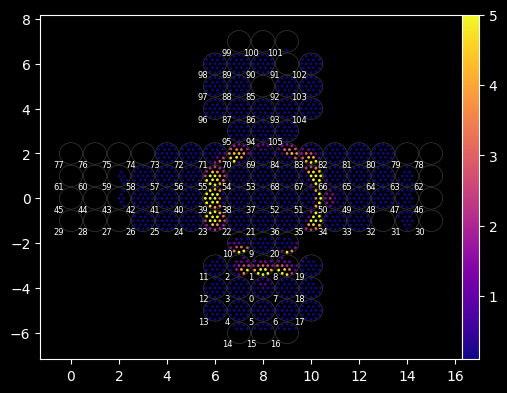

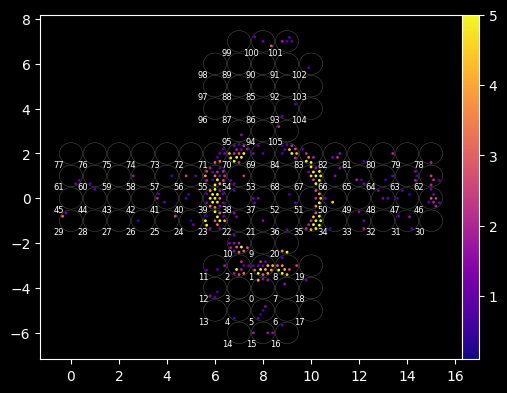

In [60]:
plot_event(np.array([result['pmt_ids'],result['exp_pes']]).T,0)
plot_event(np.array([result['pmt_ids'],result['obs_pes']]).T,0)

In [61]:
result = fit_single_hit_array(lf_data)

result['values']
# result["length_mm"]
# result["visible_length_mm"]
# result["full_range_mm"]
# result["ke0_mev"]

Particle: proton
Fit mode: absorption
Fit parameters: x0, y0, z0, cx, cy, visible_length, full_range, t0
Range table:
  min KE [MeV]: 467.0
  max KE [MeV]: 3000.0
  max range [mm]: 12099.336551086055
Fixed parameters: {'z0': -1350.0, 'full_range': 2220.0358100117446}
Fixed/derived ke0 [MeV]: 1000.0
Free parameters: ('x0', 'y0', 'cx', 'cy', 'visible_length', 't0')
Number of PMTs in fit: 1843
Number of hit PMTs: 310
Total observed PE: 967.2393382638693
Number of seed points: 162
Best seed index: 100
Best seed FCN: 772.270130453563
Best seed: {'x0': 0.0, 'y0': 0.0, 'z0': -1350.0, 'cx': 0.0, 'cy': 0.0, 'visible_length': 700.0, 'full_range': 2220.0358100117446, 't0': 0.0}

Fit result:
  length         [mm]: 711.8519515822125
  visible_length [mm]: 711.8519515822125
  full_range     [mm]: 2220.0358100117446
  ke0            [MeV]: 1000.0
  FCN: 707.3297847395183
  EDM: 7.188381685880869e-07
  valid: True


{'x0': -0.6634495802512979,
 'y0': -41.32351495373099,
 'z0': -1350.0,
 'cx': -0.00029479720345555076,
 'cy': 0.003944731279271059,
 'visible_length': 711.8519515822125,
 'full_range': 2220.0358100117446,
 't0': 0.3375028072334743}

In [62]:
range_lookup=ParticleRangeLookup('proton', table_dirs=[str(TABLES_DIR)])

In [63]:
fixed_full_range = float(range_lookup.energy_to_range_mm(1000))
fixed_full_range

2220.0358100117446

In [48]:
url = folder
fname = '/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/1kp+_1000MeV_x0y0zn1350.root'
se_name = "secondary_electron"
sep_name = 'secondary_e_photons'
ck_name = 'ck_step'
all_name = 'all_photons'
n = 800000   # number of entries to load

# Get the mapping between wcsim and wcte PMT positions
wcte_mapping = np.loadtxt('../tables/wcsim_wcte_mapping.txt')

with uproot.open(fname) as f:
    t = f[se_name]
    arr = t.arrays(library="ak", entry_stop=n)
    
    t_sep = f[sep_name]
    arr_sep = t_sep.arrays(library="ak", entry_stop=n)
    
    t_ck = f[ck_name]
    arr_ck = t_ck.arrays(library="ak", entry_stop=n)
    
    t_all = f[all_name]
    arr_all = t_all.arrays(library="ak", entry_stop=n)

df_se = ak.to_dataframe(arr).reset_index(drop=True)
df_sep = ak.to_dataframe(arr_sep).reset_index(drop=True)
df_ck = ak.to_dataframe(arr_ck).reset_index(drop=True)
df_all = ak.to_dataframe(arr_all).reset_index(drop=True)



In [64]:
evt = evt_num
df_all[df_all['evt']==evt]

,evt,trk,par,pdg,muAncestorID,edir_x,edir_y,edir_z,ex_cm,ey_cm,ez_cm,et_ns,Estart_MeV,muKE_MeV,muStep,lambda_nm,creator,hit_pmt,end_boundary,end_process
141251,4,2,1,0,1,-0.049982,0.543372,0.838003,-0.000103,-42.476471,-134.729507,0.010313,1000.0,998.580566,3,280.173309,Cerenkov,-1,WCBotCapBlackSheet,Transportation
141252,4,3,1,0,1,0.121380,-0.496982,0.859230,-0.000086,-42.476444,-134.753159,0.009411,1000.0,998.580566,3,751.587585,Cerenkov,-1,WCBarrel,OpAbsorption
141253,4,4,1,0,1,-0.141050,0.516207,0.844769,-0.000125,-42.476509,-134.697632,0.011528,1000.0,998.580566,3,325.049713,Cerenkov,-1,WCBotCapBlackSheet,Transportation
141254,4,5,1,0,1,-0.017488,0.522232,0.852624,-0.000098,-42.476463,-134.735413,0.010088,1000.0,998.580566,3,430.432220,Cerenkov,-1,WCBotCapBlackSheet,Transportation
141255,4,6,1,0,1,-0.058104,0.548511,0.834122,-0.000004,-42.476307,-134.870407,0.004940,1000.0,998.580566,3,263.254669,Cerenkov,-1,WCBotCapBlackSheet,Transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177155,4,38487,1,0,1,-0.505840,0.056853,0.860752,0.216347,-43.301670,-58.289730,2.972543,1000.0,820.302917,368,249.215591,Cerenkov,5103,pmt,Transportation
177156,4,38488,1,0,1,0.528158,-0.008164,0.849107,0.217151,-43.302887,-58.115749,2.979406,1000.0,820.302917,368,232.947113,Cerenkov,3900,pmt,Transportation
177157,4,38489,1,0,1,-0.339923,-0.326845,0.881830,0.216346,-43.301670,-58.289856,2.972538,1000.0,820.302917,368,456.982544,Cerenkov,-1,physMatrix,Transportation
177158,4,38490,1,0,1,-0.510772,-0.117597,0.851635,0.216271,-43.301556,-58.305996,2.971902,1000.0,820.302917,368,229.633423,Cerenkov,-1,WCBarrelAnnulusBlackSheet,Transportation


In [65]:
x0 = df_all[df_all['evt']==evt]['ex_cm'].iloc[0] 
y0 = df_all[df_all['evt']==evt]['ey_cm'].iloc[0] 
z0 = df_all[df_all['evt']==evt]['ez_cm'].iloc[0] 

x1 = df_all[df_all['evt']==evt]['ex_cm'].iloc[-1] 
y1 = df_all[df_all['evt']==evt]['ey_cm'].iloc[-1] 
z1 = df_all[df_all['evt']==evt]['ez_cm'].iloc[-1] 

r = np.sqrt((x1-x0)**2+(y1-y0)**2+(z1-z0)**2)

In [66]:
r

np.float32(76.52604)

In [110]:
z1

np.float32(-109.699875)

In [111]:
d = read_sim_data('/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/1kp+_1000MeV_x0y0zn1350.npz')

In [112]:
idx = np.where(d['track_id'][evt_num]==1)[0][0]

In [113]:
d['track_start_position'][evt_num][idx]

array([   0.    ,  -42.4763, -135.    ], dtype=float32)

In [114]:
d['track_stop_position'][evt_num][idx]

array([-9.27696377e-02, -4.25151176e+01, -1.09609215e+02], dtype=float32)

In [94]:
idx

np.int64(23)